In [1]:
import polars as pl
import numpy as np
from sklearn.metrics import mean_absolute_error

model_df = pl.read_parquet("../../data/clean/model_ready.parquet")
print(model_df.shape)
print(model_df.columns)

(956662, 13)
['DEST', 'date', 'arr_hour', 'arr_15min_block', 'arrivals', 'day_of_week', 'month', 'year', 'is_weekend', 'COVID_FLAG', 'hist_mean_arrivals', 'scheduled_arrivals', 'scheduled_arrivals_right']


In [2]:
train = model_df.filter(pl.col("year").is_in([2019, 2022]))
test = model_df.filter(pl.col("year") == 2023)

print("train:", train.shape)
print("test:", test.shape)

train: (717880, 13)
test: (238782, 13)


In [3]:
feature_cols = [
    "arr_hour",
    "arr_15min_block",
    "day_of_week",
    "month",
    "is_weekend",
    "scheduled_arrivals",
    "hist_mean_arrivals"
]

X_train = train.select(feature_cols).to_numpy()
y_train = train.select("arrivals").to_numpy().ravel()

X_test = test.select(feature_cols).to_numpy()
y_test = test.select("arrivals").to_numpy().ravel()

In [4]:
baseline_preds = test.select("hist_mean_arrivals").to_numpy().ravel()
baseline_mae = mean_absolute_error(y_test, baseline_preds)
print(f"baseline MAE: {baseline_mae:.4f} arrivals per 15-min slot")

baseline MAE: 0.4584 arrivals per 15-min slot


In [5]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

xgb_preds = model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_preds)

print(f"baseline MAE: {baseline_mae:.4f}")
print(f"XGBoost MAE: {xgb_mae:.4f}")
print(f"improvement: {((baseline_mae - xgb_mae) / baseline_mae * 100):.1f}%")

baseline MAE: 0.4584
XGBoost MAE: 0.0000
improvement: 100.0%


In [6]:
# compute mean from training set only
hist_mean_train = train.group_by(["DEST", "arr_hour", "day_of_week"]).agg(
    pl.col("arrivals").mean().alias("hist_mean_arrivals_fixed")
)

# join onto test set
test_fixed = test.join(
    hist_mean_train,
    on=["DEST", "arr_hour", "day_of_week"],
    how="left"
).with_columns(
    pl.col("hist_mean_arrivals_fixed").fill_null(
        pl.col("hist_mean_arrivals")
    )
)

# also remove scheduled_arrivals from features - it's too close to target
feature_cols_fixed = [
    "arr_hour",
    "arr_15min_block",
    "day_of_week",
    "month",
    "is_weekend",
    "hist_mean_arrivals_fixed"
]

X_train_fixed = train.join(
    hist_mean_train,
    on=["DEST", "arr_hour", "day_of_week"],
    how="left"
).select(feature_cols_fixed).to_numpy()

X_test_fixed = test_fixed.select(feature_cols_fixed).to_numpy()
y_test_fixed = test_fixed.select("arrivals").to_numpy().ravel()

In [7]:
model_fixed = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

model_fixed.fit(X_train_fixed, y_train)
xgb_preds_fixed = model_fixed.predict(X_test_fixed)
xgb_mae_fixed = mean_absolute_error(y_test_fixed, xgb_preds_fixed)

baseline_fixed = test_fixed.select("hist_mean_arrivals_fixed").to_numpy().ravel()
baseline_mae_fixed = mean_absolute_error(y_test_fixed, baseline_fixed)

print(f"baseline MAE: {baseline_mae_fixed:.4f}")
print(f"XGBoost MAE: {xgb_mae_fixed:.4f}")
print(f"improvement: {((baseline_mae_fixed - xgb_mae_fixed) / baseline_mae_fixed * 100):.1f}%")

baseline MAE: 0.4670
XGBoost MAE: 0.4598
improvement: 1.5%


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_dest = le.fit_transform(train["DEST"].to_numpy())
test_dest = le.transform(test_fixed["DEST"].to_numpy())

X_train_v2 = np.column_stack([X_train_fixed, train_dest])
X_test_v2 = np.column_stack([X_test_fixed, test_dest])

model_v2 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_train_v2, y_train)
preds_v2 = model_v2.predict(X_test_v2)
mae_v2 = mean_absolute_error(y_test_fixed, preds_v2)

print(f"baseline MAE:   {baseline_mae_fixed:.4f}")
print(f"XGBoost v1 MAE: {xgb_mae_fixed:.4f} — no airport encoding")
print(f"XGBoost v2 MAE: {mae_v2:.4f} — with airport encoding")
print(f"improvement over baseline: {((baseline_mae_fixed - mae_v2) / baseline_mae_fixed * 100):.1f}%")

baseline MAE:   0.4670
XGBoost v1 MAE: 0.4598 — no airport encoding
XGBoost v2 MAE: 0.4581 — with airport encoding
improvement over baseline: 1.9%


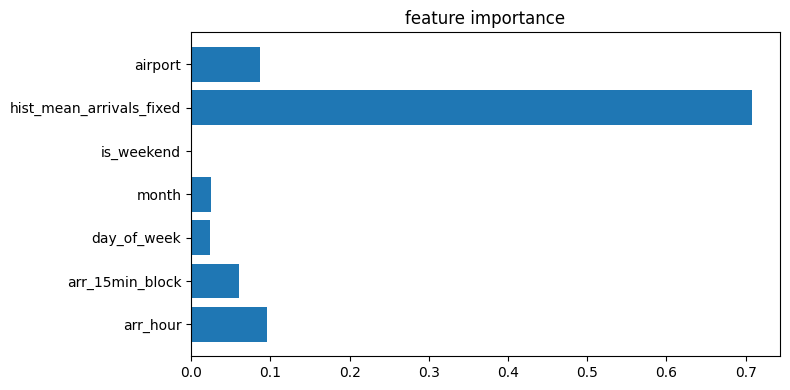

In [9]:
import matplotlib.pyplot as plt

feature_names = feature_cols_fixed + ["airport"]
importances = model_v2.feature_importances_

plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances)
plt.title("feature importance")
plt.tight_layout()
plt.show()

In [10]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# train three models - low, median, high
quantiles = {
    "q10": 0.1,
    "q50": 0.5,
    "q90": 0.9
}

q_models = {}
q_preds = {}

for name, q in quantiles.items():
    m = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        objective="reg:quantileerror",
        quantile_alpha=q,
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_train_v2, y_train)
    q_models[name] = m
    q_preds[name] = m.predict(X_test_v2)
    print(f"{name} MAE: {mean_absolute_error(y_test_fixed, q_preds[name]):.4f}")

q10 MAE: 0.3703
q50 MAE: 0.3516
q90 MAE: 0.9265


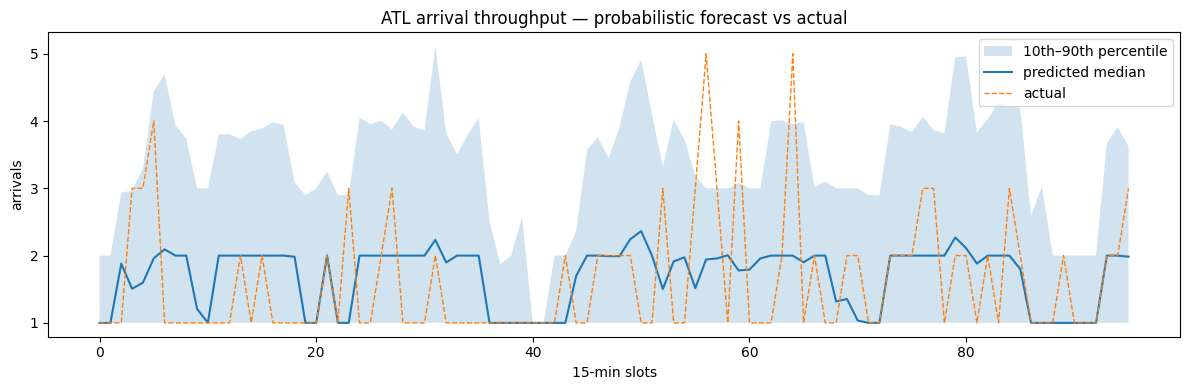

In [11]:
import matplotlib.pyplot as plt

# filter to ATL only for visualization
atl_mask = test_fixed["DEST"].to_numpy() == "ATL"
atl_actual = y_test_fixed[atl_mask][:96]  # first 96 slots = one day
atl_q10 = q_preds["q10"][atl_mask][:96]
atl_q50 = q_preds["q50"][atl_mask][:96]
atl_q90 = q_preds["q90"][atl_mask][:96]

plt.figure(figsize=(12, 4))
plt.fill_between(range(96), atl_q10, atl_q90, alpha=0.2, label="10th–90th percentile")
plt.plot(atl_q50, label="predicted median", linewidth=1.5)
plt.plot(atl_actual, label="actual", linewidth=1, linestyle="--")
plt.title("ATL arrival throughput — probabilistic forecast vs actual")
plt.xlabel("15-min slots")
plt.ylabel("arrivals")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
import os
import pickle

os.makedirs("../../models", exist_ok=True)

for name, m in q_models.items():
    with open(f"../../models/xgb_{name}.pkl", "wb") as f:
        pickle.dump(m, f)

# save label encoder too
with open("../../models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("models saved")

models saved


In [13]:
%pip install pyarrow
import importlib
importlib.invalidate_caches()
print('Installing pyarrow; restart kernel if needed')

Note: you may need to restart the kernel to use updated packages.
Installing pyarrow; restart kernel if needed



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd

# build a results dataframe
results = test_fixed.select(["DEST", "date", "arr_hour", 
                              "arr_15min_block", "arrivals",
                              "scheduled_arrivals"]).to_pandas()

results["pred_q10"] = q_preds["q10"]
results["pred_q50"] = q_preds["q50"]
results["pred_q90"] = q_preds["q90"]

# imbalance score = scheduled / predicted capacity, capped at 100
results["imbalance_score"] = (
    (results["scheduled_arrivals"] / results["pred_q50"].clip(lower=0.5)) * 20
).clip(upper=100).round(1)

print(results.groupby("DEST")["imbalance_score"].describe())

        count       mean        std   min   25%   50%   75%    max
DEST                                                              
ATL   12334.0  22.467902  12.938716   8.0  10.7  20.0  30.0  100.0
AUS    5165.0  23.725073   8.909668  20.0  20.0  20.0  20.0  100.0
BNA    5255.0  24.030447   9.444357  20.0  20.0  20.0  20.0  100.0
BOS    7366.0  25.642140  11.253499  20.0  20.0  20.0  20.0  100.0
BWI    5286.0  24.143019   9.435013  20.0  20.0  20.0  20.0  100.0
CLE    2401.0  21.624323   5.761407  20.0  20.0  20.0  20.0   60.0
CLT    7649.0  23.601870  13.120214   9.9  18.1  20.0  30.0  100.0
CVG    2420.0  21.487603   5.434591  20.0  20.0  20.0  20.0   60.0
DCA    6790.0  27.816141  13.963097  10.1  20.0  20.0  40.0  100.0
DEN   10630.0  25.976632  14.566236   8.5  20.0  20.0  36.5  100.0
DFW    9722.0  24.349259  13.413160   6.5  18.7  20.0  30.0  100.0
DTW    6411.0  24.966246  11.837218  10.0  20.0  20.0  20.0  100.0
EWR    7154.0  25.968689  11.780751  20.0  20.0  20.0  20.0  1

In [15]:
# instead of fixed multiplier, normalize per airport
# score = scheduled / predicted, expressed as % of that airport's peak capacity

airport_peak = results.groupby("DEST")["pred_q90"].quantile(0.95).rename("peak_capacity")
results = results.join(airport_peak, on="DEST")

results["imbalance_score"] = (
    (results["scheduled_arrivals"] / results["peak_capacity"]) * 100
).clip(upper=100).round(1)

print(results.groupby("DEST")["imbalance_score"].describe())

        count       mean        std   min   25%   50%    75%    max
DEST                                                               
ATL   12334.0  38.284287  21.236987  21.2  21.2  21.2   42.4  100.0
AUS    5165.0  58.276864  18.585036  50.0  50.0  50.0   50.0  100.0
BNA    5255.0  58.705994  18.962431  50.0  50.0  50.0   50.0  100.0
BOS    7366.0  61.452091  21.080712  49.8  49.8  49.8   49.8  100.0
BWI    5286.0  59.090049  19.285845  50.0  50.0  50.0   50.0  100.0
CLE    2401.0  53.852561  13.336413  50.0  50.0  50.0   50.0  100.0
CLT    7649.0  41.418813  22.422904  24.9  24.9  24.9   49.8  100.0
CVG    2420.0  53.595041  12.918851  50.0  50.0  50.0   50.0  100.0
DCA    6790.0  46.160825  20.709160  33.7  33.7  33.7   67.3  100.0
DEN   10630.0  41.191816  23.496982  23.4  23.4  23.4   46.9  100.0
DFW    9722.0  36.676877  23.195567  19.4  19.4  19.4   38.7  100.0
DTW    6411.0  40.106504  18.072421  30.6  30.6  30.6   30.6  100.0
EWR    7154.0  61.010889  21.175033  49.1  49.1 

In [16]:
results.to_parquet("../../data/clean/imbalance_scores.parquet")
print("saved")
print(results.columns.tolist())

saved
['DEST', 'date', 'arr_hour', 'arr_15min_block', 'arrivals', 'scheduled_arrivals', 'pred_q10', 'pred_q50', 'pred_q90', 'imbalance_score', 'peak_capacity']


In [17]:
sample = results[results["date"] == results["date"].max()][
    ["DEST", "imbalance_score"]
].groupby("DEST")["imbalance_score"].mean().round(1).reset_index()

print(sample)

   DEST  imbalance_score
0   ATL             34.8
1   AUS             63.0
2   BNA             61.1
3   BOS             65.5
4   BWI             53.8
5   CLE             54.2
6   CLT             42.4
7   CVG             50.0
8   DCA             48.3
9   DEN             45.3
10  DFW             37.5
11  DTW             37.0
12  EWR             55.9
13  FLL             57.9
14  HNL             58.3
15  IAD             41.2
16  IND             50.0
17  JFK             55.7
18  LAS             50.9
19  LAX             57.0
20  LGA             50.2
21  MCI             53.1
22  MCO             60.3
23  MDW             57.7
24  MIA             43.5
25  MKE             50.0
26  MSP             46.4
27  MSY             50.0
28  OAK             53.3
29  ORD             43.7
30  PDX             55.0
31  PHL             60.6
32  PHX             40.9
33  PIT             62.5
34  RDU             64.3
35  SAN             58.6
36  SAT             50.0
37  SEA             43.0
38  SJC             53.6


In [18]:
import json

score_dict = sample.set_index("DEST")["imbalance_score"].to_dict()

with open("../../data/clean/scores_sample.json", "w") as f:
    json.dump(score_dict, f, indent=2)

print(json.dumps(score_dict, indent=2))

{
  "ATL": 34.8,
  "AUS": 63.0,
  "BNA": 61.1,
  "BOS": 65.5,
  "BWI": 53.8,
  "CLE": 54.2,
  "CLT": 42.4,
  "CVG": 50.0,
  "DCA": 48.3,
  "DEN": 45.3,
  "DFW": 37.5,
  "DTW": 37.0,
  "EWR": 55.9,
  "FLL": 57.9,
  "HNL": 58.3,
  "IAD": 41.2,
  "IND": 50.0,
  "JFK": 55.7,
  "LAS": 50.9,
  "LAX": 57.0,
  "LGA": 50.2,
  "MCI": 53.1,
  "MCO": 60.3,
  "MDW": 57.7,
  "MIA": 43.5,
  "MKE": 50.0,
  "MSP": 46.4,
  "MSY": 50.0,
  "OAK": 53.3,
  "ORD": 43.7,
  "PDX": 55.0,
  "PHL": 60.6,
  "PHX": 40.9,
  "PIT": 62.5,
  "RDU": 64.3,
  "SAN": 58.6,
  "SAT": 50.0,
  "SEA": 43.0,
  "SJC": 53.6,
  "SLC": 44.9,
  "SMF": 61.8,
  "STL": 58.3,
  "TPA": 50.0
}
